<a href="https://colab.research.google.com/github/raychelbright-coder/FER-HOG-SVM/blob/main/DataScienceAss2_1ShopEase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Upload the dataset files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sales target (4).csv to Sales target (4).csv
Saving Order Details (4).csv to Order Details (4).csv
Saving List of Orders (4).csv to List of Orders (4).csv


Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              mean_absolute_error, mean_squared_error,
                              r2_score, roc_curve, auc,
                              ConfusionMatrixDisplay, classification_report)
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


### Step 3: Load and explore the dataset

In [ ]:
orders  = pd.read_csv('/content/List of Orders (4).csv')
details = pd.read_csv('/content/Order Details (4).csv')
target  = pd.read_csv('/content/Sales target (4).csv')

print('List of Orders:', orders.shape)
print('Order Details: ', details.shape)
print('Sales Target:  ', target.shape)

List of Orders: (560, 5)
Order Details:  (1500, 6)
Sales Target:   (36, 3)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [ ]:
details.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,66.0,-12.0,5,Clothing,Stole
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,168.0,-111.0,2,Electronics,Phones


In [ ]:
target.head()

,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400.0
1,May-18,Furniture,10500.0
2,Jun-18,Furniture,10600.0
3,Jul-18,Furniture,10800.0
4,Aug-18,Furniture,10900.0


### Step 4: Data Cleaning and Pre-Processing

In [ ]:
# Strip whitespace from string fields
for col in orders.select_dtypes(include='object').columns:
    orders[col] = orders[col].str.strip()
for col in details.select_dtypes(include='object').columns:
    details[col] = details[col].str.strip()

# Merge Order Details with List of Orders
df = details.merge(orders, on='Order ID', how='left')

# Convert Order Date to datetime and extract month number
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month_Num']  = df['Order Date'].dt.month

# Merge with Sales Target
df['Month_Label'] = df['Order Date'].dt.strftime('%b-%y')
df = df.merge(target, left_on=['Month_Label', 'Category'],
              right_on=['Month of Order Date', 'Category'], how='left')

print('Shape after merge:', df.shape)
df.head()

Shape after merge: (1500, 14)


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,Order Date,CustomerName,State,City,Month_Num,Month_Label,Month of Order Date,Target
0,B-25601,1275.0,-1148.0,7,Furniture,Bookcases,2018-04-01,Bharat,Gujarat,Ahmedabad,4,Apr-18,Apr-18,10400.0
1,B-25601,66.0,-12.0,5,Clothing,Stole,2018-04-01,Bharat,Gujarat,Ahmedabad,4,Apr-18,Apr-18,12000.0
2,B-25601,8.0,-2.0,3,Clothing,Hankerchief,2018-04-01,Bharat,Gujarat,Ahmedabad,4,Apr-18,Apr-18,12000.0
3,B-25601,80.0,-56.0,4,Electronics,Electronic Games,2018-04-01,Bharat,Gujarat,Ahmedabad,4,Apr-18,Apr-18,9000.0
4,B-25602,168.0,-111.0,2,Electronics,Phones,2018-04-01,Pearl,Maharashtra,Pune,4,Apr-18,Apr-18,9000.0


In [ ]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
Order ID               0
Amount                 0
Profit                 0
Quantity               0
Category               0
Sub-Category           0
Order Date             0
CustomerName           0
State                  0
City                   0
Month_Num              0
Month_Label            0
Month of Order Date    0
Target                 0
dtype: int64


In [ ]:
# Remove rows with missing or invalid values
before = len(df)
df.dropna(subset=['Amount', 'Profit', 'Quantity'], inplace=True)
df = df[(df['Amount'] > 0) & (df['Quantity'] > 0)]
print(f'Rows before cleaning: {before}')
print(f'Rows after cleaning:  {len(df)}')

Rows before cleaning: 1500
Rows after cleaning:  1500


In [ ]:
# Descriptive statistics – mean, std, variance
print('Overall statistics:')
print(df[['Amount', 'Profit', 'Quantity']].describe().round(2))

print('\nVariance:')
print(df[['Amount', 'Profit', 'Quantity']].var().round(2))

Overall statistics:
        Amount   Profit  Quantity
count  1500.00  1500.00   1500.00
mean    287.67    15.97      3.74
std     461.05   169.14      2.18
min       4.00 -1981.00      1.00
25%      45.00    -9.25      2.00
50%     118.00     9.00      3.00
75%     322.00    38.00      5.00
max    5729.00  1698.00     14.00

Variance:
Amount      212567.55
Profit       28608.53
Quantity         4.77
dtype: float64


In [ ]:
# Summary statistics by Category
summary = df.groupby('Category').agg(
    Count          = ('Amount',  'count'),
    Mean_Amount    = ('Amount',  'mean'),
    Std_Amount     = ('Amount',  'std'),
    Median_Profit  = ('Profit',  'median'),
    Variance_Profit= ('Profit',  'var'),
    Total_Amount   = ('Amount',  'sum')
).round(2)
print(summary)

             Count  Mean_Amount  Std_Amount  Median_Profit  Variance_Profit  \
Category                                                                      
Clothing       949       146.53      258.96            8.0          6185.93   
Electronics    308       536.58      551.46           21.5         62002.52   
Furniture      243       523.38      674.86           13.0         73789.78   

             Total_Amount  
Category                   
Clothing         139054.0  
Electronics      165267.0  
Furniture        127181.0  


In [ ]:
# Identify outliers using standard deviation
mean_profit = df['Profit'].mean()
std_profit  = df['Profit'].std()

outliers = df[np.abs(df['Profit'] - mean_profit) > 3 * std_profit]
print(f'Mean Profit: {mean_profit:.2f}')
print(f'Std Profit:  {std_profit:.2f}')
print(f'Outliers found (beyond 3 std): {len(outliers)}')
print(outliers[['Category', 'Sub-Category', 'Amount', 'Profit']])

Mean Profit: 15.97
Std Profit:  169.14
Outliers found (beyond 3 std): 36
         Category      Sub-Category  Amount  Profit
0       Furniture         Bookcases  1275.0 -1148.0
6     Electronics            Phones  2617.0  1151.0
22      Furniture            Tables  1364.0 -1864.0
31    Electronics          Printers   781.0  -594.0
138   Electronics          Printers  1279.0  -640.0
173      Clothing             Saree  1389.0   680.0
198   Electronics  Electronic Games   934.0  -916.0
236   Electronics  Electronic Games  1096.0  -658.0
249   Electronics          Printers   332.0  -503.0
368   Electronics            Phones  1145.0  -706.0
462      Clothing          Trousers  1709.0   564.0
467     Furniture         Bookcases   729.0  -492.0
483     Furniture         Bookcases  2188.0  1050.0
489   Electronics  Electronic Games  1316.0  -527.0
529     Furniture            Tables  1361.0  -980.0
585     Furniture            Tables  1630.0  -802.0
589     Furniture         Bookcases  2830.0

In [ ]:
# Remove outliers for modelling
df_model = df[np.abs(df['Profit'] - mean_profit) <= 3 * std_profit].copy()
print(f'Rows before: {len(df)}')
print(f'Rows after:  {len(df_model)}')

# Encode Category as a number
le = LabelEncoder()
df_model['Category_Enc'] = le.fit_transform(df_model['Category'])

# Create binary High_Profit label for classification
df_model['High_Profit'] = (df_model['Profit'] > df_model['Profit'].median()).astype(int)
print(f'\nHigh Profit orders: {df_model["High_Profit"].sum()}')
print(f'Low Profit orders:  {(df_model["High_Profit"] == 0).sum()}')

Rows before: 1500
Rows after:  1464

High Profit orders: 714
Low Profit orders:  750


### Step 5: Visualisations

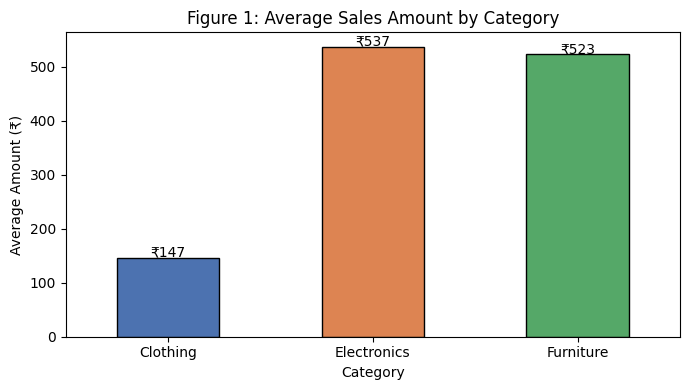

In [ ]:
# Figure 1: Average Amount by Category
avg_amount = df.groupby('Category')['Amount'].mean()

plt.figure(figsize=(7, 4))
avg_amount.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
plt.title('Figure 1: Average Sales Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Amount (₹)')
plt.xticks(rotation=0)
for i, v in enumerate(avg_amount):
    plt.text(i, v + 2, f'₹{v:.0f}', ha='center')
plt.tight_layout()
plt.show()

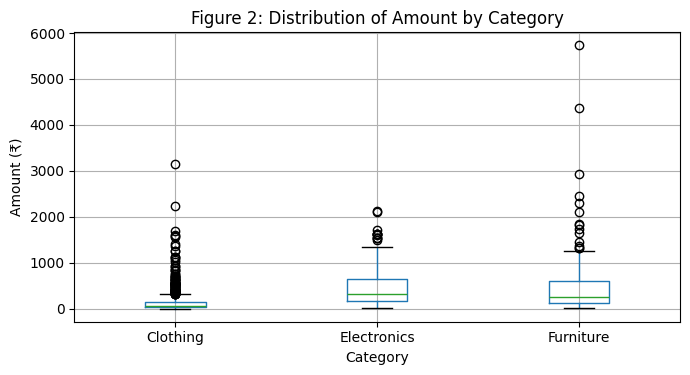

In [ ]:
# Figure 2: Distribution of Amount by Category
df_model.boxplot(column='Amount', by='Category', figsize=(7, 4))
plt.title('Figure 2: Distribution of Amount by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.show()

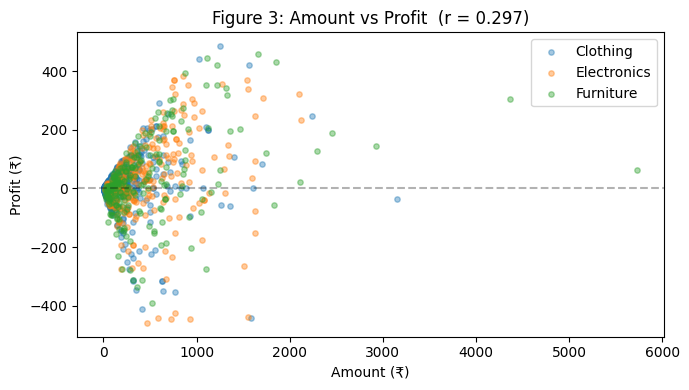

Pearson r = 0.297, p = 0.0000


In [ ]:
# Figure 3: Scatter plot – Amount vs Profit
plt.figure(figsize=(7, 4))
for cat, grp in df_model.groupby('Category'):
    plt.scatter(grp['Amount'], grp['Profit'], label=cat, alpha=0.4, s=15)

r, p = pearsonr(df_model['Amount'], df_model['Profit'])
plt.title(f'Figure 3: Amount vs Profit  (r = {r:.3f})')
plt.xlabel('Amount (₹)')
plt.ylabel('Profit (₹)')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f'Pearson r = {r:.3f}, p = {p:.4f}')

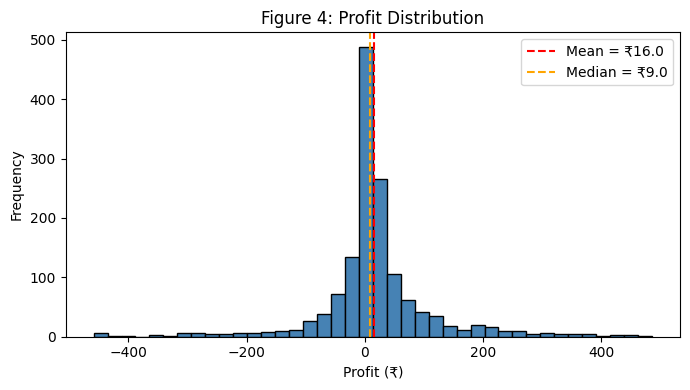

In [ ]:
# Figure 4: Profit Distribution
plt.figure(figsize=(7, 4))
plt.hist(df_model['Profit'], bins=40, color='steelblue', edgecolor='black')
plt.axvline(df_model['Profit'].mean(),   color='red',    linestyle='--',
            label=f"Mean = ₹{df_model['Profit'].mean():.1f}")
plt.axvline(df_model['Profit'].median(), color='orange', linestyle='--',
            label=f"Median = ₹{df_model['Profit'].median():.1f}")
plt.title('Figure 4: Profit Distribution')
plt.xlabel('Profit (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

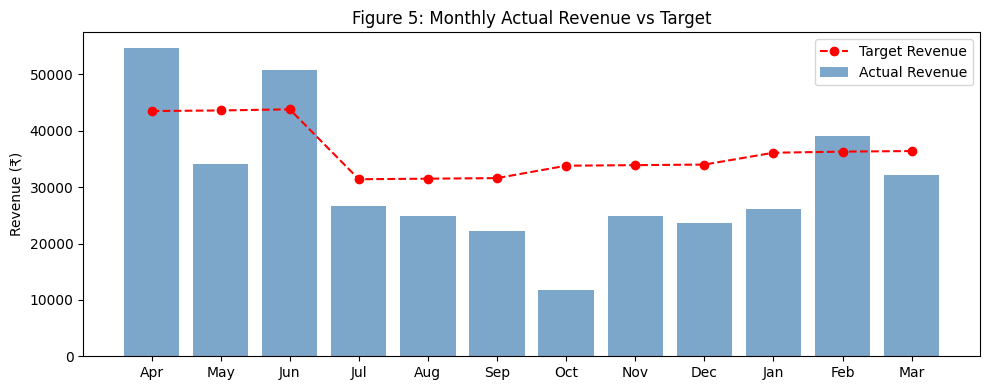

In [ ]:
# Figure 5: Monthly Revenue vs Target
monthly_rev = df_model.groupby('Month_Num')['Amount'].sum()
target['Month_Num'] = pd.to_datetime(
    target['Month of Order Date'], format='%b-%y').dt.month
monthly_target = target.groupby('Month_Num')['Target'].sum()

month_labels = ['Apr','May','Jun','Jul','Aug','Sep',
                'Oct','Nov','Dec','Jan','Feb','Mar']
x = list(range(1, 13))

plt.figure(figsize=(10, 4))
plt.bar(x, [monthly_rev.get(i, 0) for i in x],
        color='steelblue', alpha=0.7, label='Actual Revenue')
plt.plot(x, [monthly_target.get(i, 0) for i in x],
         'r--o', label='Target Revenue')
plt.xticks(x, month_labels)
plt.title('Figure 5: Monthly Actual Revenue vs Target')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.tight_layout()
plt.show()

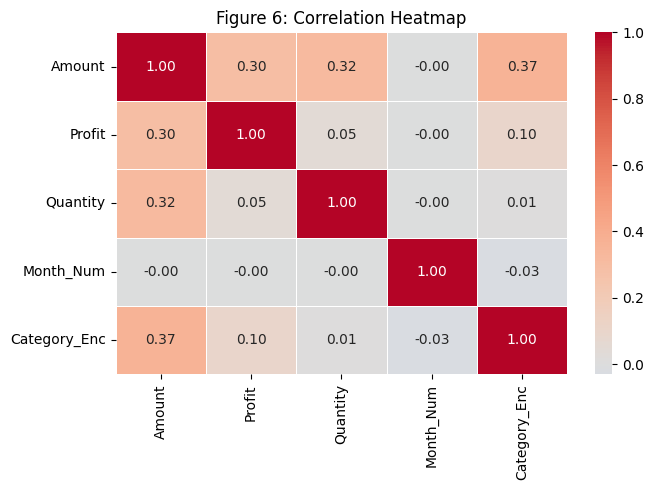

In [ ]:
# Figure 6: Correlation Heatmap
plt.figure(figsize=(7, 5))
corr_cols = ['Amount', 'Profit', 'Quantity', 'Month_Num', 'Category_Enc']
sns.heatmap(df_model[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Figure 6: Correlation Heatmap')
plt.tight_layout()
plt.show()

### Step 6: Linear Regression – Predicting Profit

Independent variables (X): Amount, Quantity, Category, Month

Dependent variable (y): Profit

In [ ]:
X = df_model[['Amount', 'Quantity', 'Category_Enc', 'Month_Num']].values
y = df_model['Profit'].values

# Split into Training set (70%) and Test set (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print('Training set:', len(X_train))
print('Test set:    ', len(X_test))

Training set: 1024
Test set:     440


In [ ]:
# Fit Linear Regression to the Training set
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict the Test set results
y_pred = regressor.predict(X_test)

# Compare actual vs predicted
print('Actual:   ', y_test[:10].round(2))
print('Predicted:', y_pred[:10].round(2))

Actual:    [ 88.  72. -42.  77.  29. 122.  19.   6.   0.  14.]
Predicted: [42.24 -2.35  2.67 11.87  7.29 14.13 -2.61 25.   10.65 -5.11]


In [ ]:
# Evaluate the model
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

MAE:  49.83
MSE:  9043.20
RMSE: 95.10
R²:   0.0151


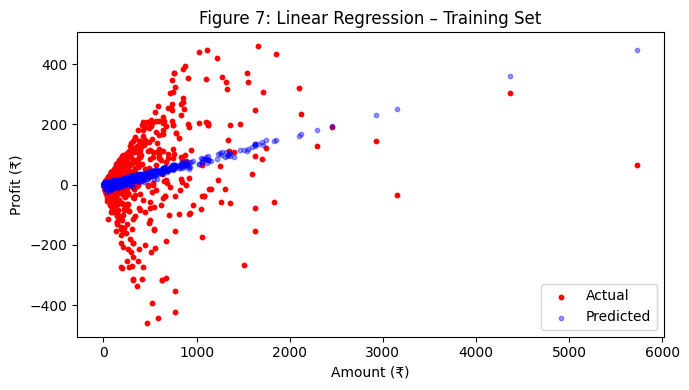

In [ ]:
# Figure 7: Visualise Training set results
plt.figure(figsize=(7, 4))
plt.scatter(X_train[:, 0], y_train, color='red',  s=10, label='Actual')
plt.scatter(X_train[:, 0], regressor.predict(X_train),
            color='blue', s=10, alpha=0.4, label='Predicted')
plt.title('Figure 7: Linear Regression – Training Set')
plt.xlabel('Amount (₹)')
plt.ylabel('Profit (₹)')
plt.legend()
plt.tight_layout()
plt.show()

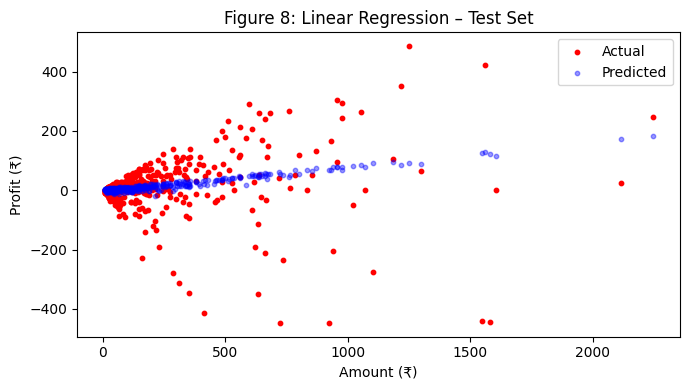

In [ ]:
# Figure 8: Visualise Test set results
plt.figure(figsize=(7, 4))
plt.scatter(X_test[:, 0], y_test, color='red',  s=10, label='Actual')
plt.scatter(X_test[:, 0], y_pred, color='blue', s=10, alpha=0.4, label='Predicted')
plt.title('Figure 8: Linear Regression – Test Set')
plt.xlabel('Amount (₹)')
plt.ylabel('Profit (₹)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Check for overfitting
r2_train = r2_score(y_train, regressor.predict(X_train))
r2_test  = r2_score(y_test,  y_pred)
print(f'R² Training set: {r2_train:.4f}')
print(f'R² Test set:     {r2_test:.4f}')
print()
if abs(r2_train - r2_test) > 0.1:
    print('Large gap – signs of overfitting')
else:
    print('Small gap – model generalises well')

R² Training set: 0.1181
R² Test set:     0.0151

Large gap – signs of overfitting


In [ ]:
# Cross validation
cv_scores = cross_val_score(regressor, X, y, cv=5, scoring='r2')
print(f'CV R² scores: {cv_scores.round(4)}')
print(f'Mean CV R²:   {cv_scores.mean():.4f}')

CV R² scores: [-0.3562 -0.387  -0.6891  0.0882 -0.1344]
Mean CV R²:   -0.2957


### Step 7: Logistic Regression – Classifying High vs Low Profit

Target: High_Profit (1 = above median profit, 0 = below median profit)

In [ ]:
X_clf = df_model[['Amount', 'Quantity', 'Category_Enc', 'Month_Num']].values
y_clf = df_model['High_Profit'].values

# Split into Training set and Test set
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42)

# Feature scaling
sc = StandardScaler()
X_train_c = sc.fit_transform(X_train_c)
X_test_c  = sc.transform(X_test_c)

print('Training set:', len(X_train_c))
print('Test set:    ', len(X_test_c))

Training set: 1024
Test set:     440


In [ ]:
# Fit Logistic Regression to the Training set
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_c, y_train_c)

# Predict the Test set results
y_pred_c = classifier.predict(X_test_c)

print('Predicted:', y_pred_c[:10])
print('Actual:   ', y_test_c[:10])

Predicted: [1 1 0 0 0 0 1 0 1 0]
Actual:    [1 1 0 1 1 1 1 0 0 1]


In [ ]:
# Confusion Matrix
cm  = confusion_matrix(y_test_c, y_pred_c)
acc = accuracy_score(y_test_c, y_pred_c)
print('Confusion Matrix:')
print(cm)
print(f'\nAccuracy: {acc:.4f}')
print()
print(classification_report(y_test_c, y_pred_c,
      target_names=['Low Profit', 'High Profit']))

Confusion Matrix:
[[194  40]
 [125  81]]

Accuracy: 0.6250

              precision    recall  f1-score   support

  Low Profit       0.61      0.83      0.70       234
 High Profit       0.67      0.39      0.50       206

    accuracy                           0.62       440
   macro avg       0.64      0.61      0.60       440
weighted avg       0.64      0.62      0.61       440



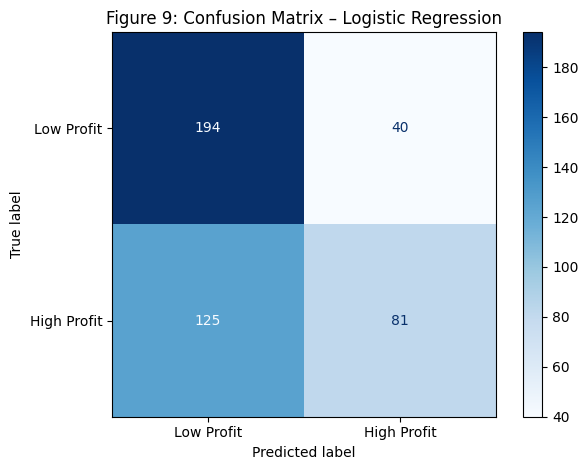

In [ ]:
# Figure 9: Visualise Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['Low Profit', 'High Profit']).plot(cmap='Blues')
plt.title('Figure 9: Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

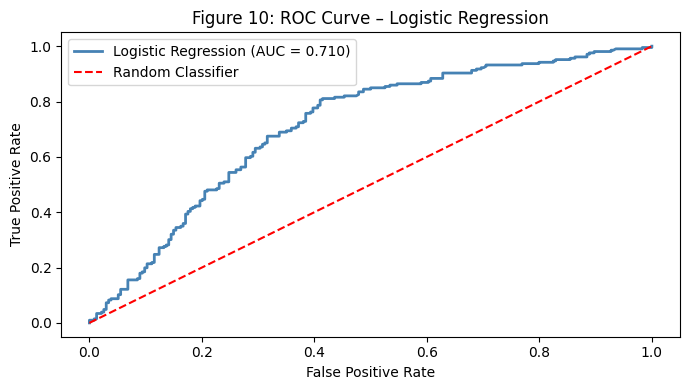

AUC = 0.710  (above 0.5 = better than random)


In [ ]:
# Figure 10: ROC Curve
y_prob = classifier.predict_proba(X_test_c)[:, 1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 4))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'r--', label='Random Classifier')
plt.title('Figure 10: ROC Curve – Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()
print(f'AUC = {roc_auc:.3f}  (above 0.5 = better than random)')

In [ ]:
# Cross validation
cv_log = cross_val_score(LogisticRegression(random_state=42),
                         sc.fit_transform(X_clf), y_clf,
                         cv=5, scoring='accuracy')
print(f'CV Accuracy scores: {cv_log.round(4)}')
print(f'Mean CV Accuracy:   {cv_log.mean():.4f}')

CV Accuracy scores: [0.5734 0.4949 0.5597 0.157  0.6199]
Mean CV Accuracy:   0.4810


### Step 8: Decision Tree Classifier

In [ ]:
# Fit Decision Tree to the Training set
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train_c, y_train_c)

# Predict the Test set results
y_pred_dt = dt_classifier.predict(X_test_c)

cm_dt  = confusion_matrix(y_test_c, y_pred_dt)
acc_dt = accuracy_score(y_test_c, y_pred_dt)
print('Confusion Matrix:')
print(cm_dt)
print(f'\nAccuracy: {acc_dt:.4f}')
print()
print(classification_report(y_test_c, y_pred_dt,
      target_names=['Low Profit', 'High Profit']))

Confusion Matrix:
[[178  56]
 [ 68 138]]

Accuracy: 0.7182

              precision    recall  f1-score   support

  Low Profit       0.72      0.76      0.74       234
 High Profit       0.71      0.67      0.69       206

    accuracy                           0.72       440
   macro avg       0.72      0.72      0.72       440
weighted avg       0.72      0.72      0.72       440



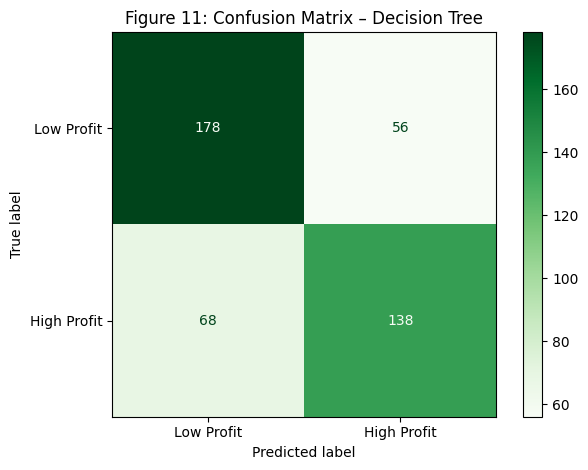

In [ ]:
# Figure 11: Confusion Matrix – Decision Tree
ConfusionMatrixDisplay(confusion_matrix=cm_dt,
    display_labels=['Low Profit', 'High Profit']).plot(cmap='Greens')
plt.title('Figure 11: Confusion Matrix – Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
# Cross validation
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                        sc.fit_transform(X_clf), y_clf,
                        cv=5, scoring='accuracy')
print(f'CV Accuracy scores: {cv_dt.round(4)}')
print(f'Mean CV Accuracy:   {cv_dt.mean():.4f}')

CV Accuracy scores: [0.5085 0.4471 0.3481 0.2321 0.5171]
Mean CV Accuracy:   0.4106


### Step 9: Experiment – Varying Decision Tree Depth

Testing different max_depth values to find the best model and understand overfitting.

In [ ]:
depths       = [2, 3, 5, 7, 10]
train_scores = []
test_scores  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_c, y_train_c)
    train_scores.append(accuracy_score(y_train_c, dt.predict(X_train_c)))
    test_scores.append(accuracy_score(y_test_c,  dt.predict(X_test_c)))

print(f'{'Depth':<8} {'Train Acc':>10} {'Test Acc':>10}')
for d, tr, te in zip(depths, train_scores, test_scores):
    print(f'{d:<8} {tr:>10.4f} {te:>10.4f}')

Depth     Train Acc   Test Acc
2            0.6621     0.6273
3            0.7822     0.7341
5            0.7959     0.7182
7            0.8320     0.7273
10           0.8965     0.6886


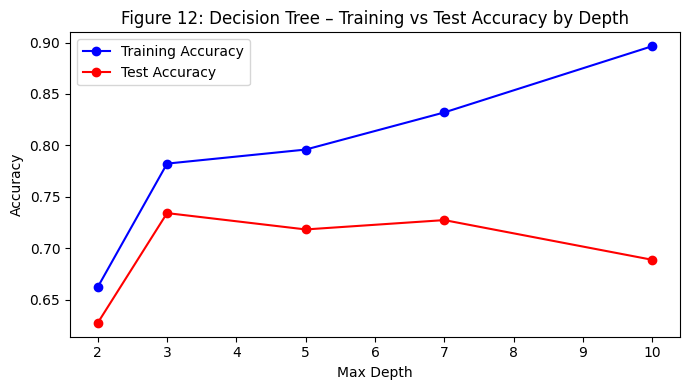

As depth increases, training accuracy rises but test accuracy levels off.
This shows overfitting at higher depths.


In [ ]:
# Figure 12: Training vs Test Accuracy by Depth
plt.figure(figsize=(7, 4))
plt.plot(depths, train_scores, 'b-o', label='Training Accuracy')
plt.plot(depths, test_scores,  'r-o', label='Test Accuracy')
plt.title('Figure 12: Decision Tree – Training vs Test Accuracy by Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
print('As depth increases, training accuracy rises but test accuracy levels off.')
print('This shows overfitting at higher depths.')

### Step 10: Results Summary

In [ ]:
print('=' * 50)
print('LINEAR REGRESSION – Profit Prediction')
print('=' * 50)
print(f'MAE:          {mae:.2f}')
print(f'RMSE:         {rmse:.2f}')
print(f'R²:           {r2:.4f}')
print(f'Mean CV R²:   {cv_scores.mean():.4f}')

print()
print('=' * 50)
print('LOGISTIC REGRESSION – High/Low Profit Classification')
print('=' * 50)
print(f'Accuracy:        {acc:.4f}')
print(f'Mean CV Accuracy:{cv_log.mean():.4f}')
print(f'AUC:             {roc_auc:.3f}')

print()
print('=' * 50)
print('DECISION TREE – High/Low Profit Classification')
print('=' * 50)
print(f'Accuracy:        {acc_dt:.4f}')
# Calculate cv_dt here to resolve the NameError if the previous cell was not executed
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                        sc.fit_transform(X_clf), y_clf,
                        cv=5, scoring='accuracy')
print(f'Mean CV Accuracy:{cv_dt.mean():.4f}')

LINEAR REGRESSION – Profit Prediction
MAE:          49.83
RMSE:         95.10
R²:           0.0151
Mean CV R²:   -0.2957

LOGISTIC REGRESSION – High/Low Profit Classification
Accuracy:        0.6250
Mean CV Accuracy:0.4810
AUC:             0.710

DECISION TREE – High/Low Profit Classification
Accuracy:        0.7182
Mean CV Accuracy:0.4106
